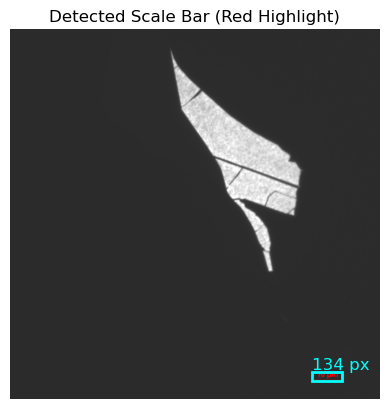

134

In [10]:
# Re-import necessary libraries after code execution state reset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Reload the image
image_path = "with-fluoresence(1).png"
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)

# Extract RGB channels
red_channel = img_np[:, :, 0]
green_channel = img_np[:, :, 1]
blue_channel = img_np[:, :, 2]

# Create a mask for bright red pixels
red_mask = (red_channel > 180) & (green_channel < 50) & (blue_channel < 50)

# Find bounding box of the red pixels (scale bar)
coords = np.column_stack(np.where(red_mask))
ymin, xmin = coords.min(axis=0)
ymax, xmax = coords.max(axis=0)

# Calculate the pixel length of the scale bar
scale_bar_length_px = xmax - xmin

# Display result
fig, ax = plt.subplots()
ax.imshow(img)
ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, edgecolor='cyan', facecolor='none', lw=2))
ax.text(xmin, ymin - 10, f"{scale_bar_length_px} px", color='cyan', fontsize=12)
ax.set_title("Detected Scale Bar (Red Highlight)")
plt.axis('off')
plt.show()

scale_bar_length_px


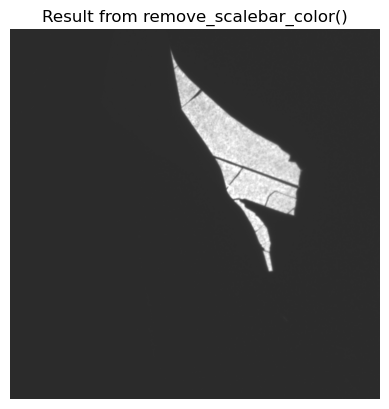

In [11]:
def remove_scalebar_color(img_np):
    """
    Replace all red scale bar pixels in an RGB image with the darkest natural pixel color in the image.

    Parameters:
        img_np (np.ndarray): RGB image as a NumPy array.

    Returns:
        np.ndarray: Modified image with red pixels recolored.
    """
    # Extract RGB channels
    red_channel = img_np[:, :, 0]
    green_channel = img_np[:, :, 1]
    blue_channel = img_np[:, :, 2]

    # Create a mask for bright red pixels (scale bar)
    red_mask = (red_channel > 180) & (green_channel < 50) & (blue_channel < 50)

    # Convert image to grayscale (min RGB approximation) to find the darkest value
    gray_img = np.min(img_np, axis=2)
    darkest_value = gray_img[~red_mask].min()  # ignore scale bar pixels

    # Find a pixel with the darkest value
    darkest_mask = (gray_img == darkest_value)
    sample_y, sample_x = np.argwhere(darkest_mask)[0]
    darkest_rgb = img_np[sample_y, sample_x]

    # Replace red pixels with the sampled darkest RGB value
    img_recolored = img_np.copy()
    img_recolored[red_mask] = darkest_rgb

    return img_recolored

# Apply the function
image_cleaned = remove_scalebar_color(img_np)

# Display the result
plt.imshow(image_cleaned)
plt.axis('off')
plt.title("Result from remove_scalebar_color()")
plt.show()

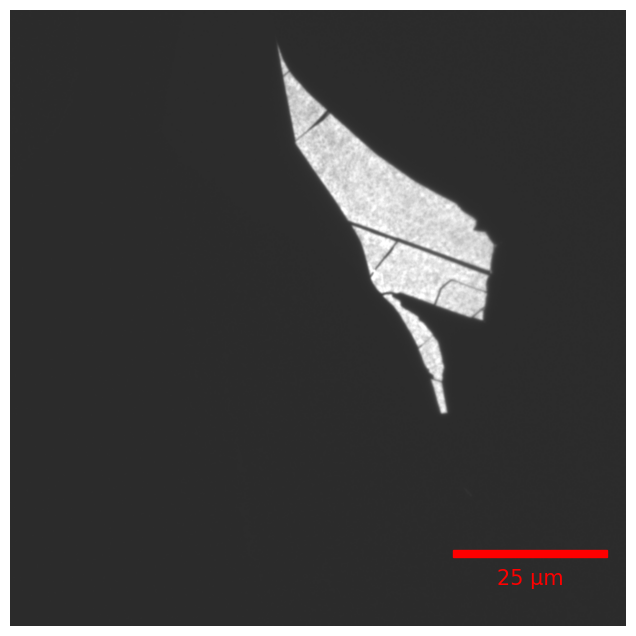

In [12]:

from matplotlib import patches

def add_Scale_to_image(img, scale_bar_length_px, scale_bar_label, bar_height=20, bar_color='red'):
    """
    Adds a scale bar to the image.
    
    Parameters:
    - img: PIL Image object
    - scale_bar_length_px: Length of the scale bar in pixels
    - scale_bar_label: Label for the scale bar
    - bar_height: Height of the scale bar in pixels
    - bar_color: Color of the scale bar
    """
    # Convert NumPy array to PIL Image if necessary
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.axis('off')




    # Positioning the scale bar
    bar_x = img.width - scale_bar_length_px - 50
    bar_y = img.height - 200

    # Add scale bar rectangle
    scale_bar = patches.Rectangle((bar_x, bar_y), scale_bar_length_px, bar_height, color=bar_color)
    ax.add_patch(scale_bar)

    # Add scale bar label
    ax.text(
        bar_x + scale_bar_length_px / 2,
        bar_y + bar_height + 30,
        scale_bar_label,
        color=bar_color,
        fontsize=15,
        ha='center',
        va='top'
    )

    return fig, ax


fig, ax = add_Scale_to_image(
    image_cleaned,
    scale_bar_length_px=134*3,  # 134px per 10 µm
    scale_bar_label="25 µm",
    bar_height=20,
    bar_color='red'
)   

plt.savefig("opticalflake-with-fluoro.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()